# Week 07: Building the diffusion forward pass

Up to now you have built a fully analytic generative model: given a cycle's
amplitude, the **classical statistical model** from Weeks 03–06 emits a
per-year Gaussian over absolute emergence latitude, and you sample from it
directly. The model is interpretable and physically motivated, but it is also
a strong assumption — a single Gaussian per year, with shape parameters that
depend linearly on amplitude. Looking at the empirical distributions, you have
already seen places where the Gaussian fit leaves structure on the table:
bimodality at certain phases of certain cycles, asymmetric tails, year-to-year
fluctuations that a smooth analytic model cannot reproduce.

The goal of the next three weeks is to model what the classical model leaves
behind. For each 6-month window of each hemispheric cycle we will compute the
**residual** — the difference between the empirical latitude histogram and the
parametric histogram — and train a **score-based diffusion model** to generate
plausible residuals. The full generative model becomes *classical statistical
model + sampled residual*. If the diffusion model has learned anything
systematic, the combined model should outperform the classical model alone on
the scoreboard NLL.

**Strategic split across the three weeks.** A diffusion model has two parts:
a **forward process** that progressively corrupts data into noise (purely
numerical — no learning involved), and a **reverse process** that
progressively undoes the corruption (the learned part — a neural network).
All the diffusion-specific mathematics lives in the forward process; the
reverse process is a standard regression problem dressed in PyTorch. We
exploit this separation deliberately:

- **Week 07 (this notebook):** Build the dataset of residuals and implement
  the forward process in pure numpy. By the end of this week you will be able
  to take a real residual and watch it dissolve into Gaussian noise across
  T timesteps, with every line of code transparent and debuggable.
- **Week 08:** Build the AI/ML pipeline (PyTorch + Lightning) and train an
  **unconditional** diffusion model that learns the marginal distribution of
  residuals. Sample from it and verify that the samples match the training
  distribution.
- **Week 09:** Add **conditioning** on (cycle amplitude, universal-path
  latitude). Sample residuals for held-out test cycles, combine with the
  classical model, and run the result through `compute_global_nll`.

By the end of Week 09 you will have a working **conditional generative model**
for the butterfly diagram that learns from data what the classical model
misses. This week is the foundation: get the forward process exactly right,
and the rest is standard deep learning.

**By the end of this notebook you should be able to:**
- Explain what a **residual** is in vector form, and why each one is a single
  point in a 15-dimensional space (not a function of latitude).
- Construct a **stratified** training / validation / test split by
  hemispheric cycle amplitude, and explain why all three splits are needed
  for diffusion training.
- Implement and visualize a **cosine noise schedule** with T = 200 timesteps,
  and read off α_t, σ_t, and the **signal-to-noise ratio** SNR(t) at any
  point on the schedule.
- Apply the **forward corruption** r_t = α_t · r + σ_t · ε to map any clean
  residual to any noise level in a single step.
- Verify empirically that at t = T the corrupted residuals are
  indistinguishable from N(0, I), regardless of the original residual — this
  is the property that lets the reverse process start from pure noise next
  week.


In [6]:
import os, subprocess, sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
#repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [7]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm as sp_norm

# ── locate repo root robustly (works regardless of Jupyter launch directory) ──
# Use the repo_path variable defined in the previous setup cell.
# The 'repo_path' variable is '/content/butterflai' from the previous cell.
_repo_root = repo_path
_week8_dir = os.path.join(_repo_root, "weeks", "week_08")

# Verify that the butterflAI_model.py file exists at the expected location.
if not os.path.isfile(os.path.join(_week8_dir, "butterflAI_model.py")):
    raise FileNotFoundError(
        f"Cannot locate butterflAI_model.py at '{os.path.join(_week8_dir, 'butterflAI_model.py')}'. "
        "Please ensure the butterflai repository was cloned correctly and contains the 'weeks/week_08' directory and its contents."
    )

for _p in [_week8_dir, _repo_root]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── raw sunspot data ──────────────────────────────────────────────────────────
data_path = Path(_repo_root) / "data" / "composite_sunspot_groups_peak_area.csv"
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)
df = df[df["latitude"].notna()].copy()
df["hemisphere"]   = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
df["abs_latitude"] = df["latitude"].abs()
df["year"]         = df["date"].dt.year
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25
df = df[df["correctedArea"] > 30].copy()

# ── official model (imported directly — weeks/ has no __init__.py) ────────────
from butterflAI_model import ButterflAIModel
model = ButterflAIModel(os.path.join(_week8_dir, "official_model.npz"))
print(model)

# ── 12-month smoothed hemispheric area (amplitude proxy) ─────────────────────
# Filter: cycles in the model and correctedArea > 50 MSH (noise floor)
cycles_in_model = sorted({c for c, _ in model.known_hemicycles()})
df_amp = df[df["CYCLE"].isin(cycles_in_model) & (df["correctedArea"] > 50)].copy()

daily_north = df_amp[df_amp["hemisphere"] == "north"].groupby("date")["correctedArea"].sum()
daily_south = df_amp[df_amp["hemisphere"] == "south"].groupby("date")["correctedArea"].sum()
date_range  = pd.date_range(
    min(daily_north.index.min(), daily_south.index.min()),
    max(daily_north.index.max(), daily_south.index.max()),
    freq="D",
)
daily_north  = daily_north.reindex(date_range, fill_value=0)
daily_south  = daily_south.reindex(date_range, fill_value=0)
smooth_north = daily_north.rolling(365, center=True, min_periods=120).mean()
smooth_south = daily_south.rolling(365, center=True, min_periods=120).mean()

# Peak amplitude per hemicycle
peak_records = []
for cyc, hemi in model.known_hemicycles():
    cyc_dates = df[df["CYCLE"] == cyc]["date"]
    if len(cyc_dates) == 0:
        continue
    d_min, d_max = cyc_dates.min(), cyc_dates.max()
    smooth = smooth_north if hemi == "north" else smooth_south
    seg    = smooth[(smooth.index >= d_min) & (smooth.index <= d_max)].dropna()
    if len(seg) == 0:
        continue
    peak_records.append(dict(
        cycle=int(cyc), hemisphere=hemi,
        peak_date=seg.idxmax(), peak_amplitude=float(seg.max()),
    ))

peaks_df   = pd.DataFrame(peak_records).sort_values(["cycle", "hemisphere"]).reset_index(drop=True)
amp_lookup = {(r["cycle"], r["hemisphere"]): r["peak_amplitude"] for _, r in peaks_df.iterrows()}

# Convenience column name lists (used throughout the notebook)
hist_cols = [f"hist_emp_{j:02d}" for j in range(15)]
par_cols  = [f"hist_par_{j:02d}" for j in range(15)]

print(f"\nLoaded {len(df):,} sunspot group records  |  "
      f"{len(peaks_df)} hemicycles with amplitude estimates")

/tmp/ipykernel_742/1333782016.py:27: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_742/1333782016.py:27: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>

Loaded 32,349 sunspot group records  |  26 hemicycles with amplitude estimates


---
# Week 07 Tasks: Building the Diffusion Forward Pass

Everything above this line is **recap and setup** — the classical statistical
model from Weeks 03–06, the per-cycle shape fits, and the global scoreboard
metric. Below this line begins the Week 07 work proper: turn the classical
model into a dataset of residuals, define the splits, and implement the
forward diffusion process in pure numpy.

The tasks build sequentially. Tasks 26–27 prepare the data; Tasks 28–29
implement the forward process; Tasks 30–32 verify it behaves the way the
mathematics says it should.


---
## Task 26 — Build the per-window dataset table

The training data for the diffusion model is a table where each row is one
**6-month window** of one hemispheric cycle, and the most important columns
are the empirical and parametric latitude histograms for that window. The
**residual** for the window is then *empirical histogram − parametric
histogram*, both expressed as densities on the same latitude grid.

Two design choices to flag explicitly before you start, because they affect
every downstream task:

- **Non-overlapping 6-month windows.** Each calendar half-year contributes one
  row. An alternative would be sliding 6-month windows that step by, say,
  one month — that gives more rows but they are not statistically
  independent. We choose non-overlapping windows so that "row count" and
  "independent observation count" are the same number.
- **15 latitude bins of 3° width covering 0°–45°.** The Spörer zone is
  bounded between roughly 5° and 40°, so bins 0 (0°–3°) and 14 (42°–45°)
  will be near-empty for most cycles. We keep them anyway: the residual at
  those bins is small *by construction*, and the diffusion model will learn
  this trivial structure quickly. Trimming the grid would create a special
  case that is more confusing than useful.

**Tasks:**
- For every (cycle, hemisphere) with `cycle ≥ 12`, identify the calendar
  span of the cycle and partition it into consecutive non-overlapping
  6-month windows. Discard any window with fewer than 20 observed sunspot
  group emergences (too few to form a meaningful histogram).
- For each retained window, compute and store as columns:
  - `cycle`, `hemisphere`.
  - `amplitude` — the **hemispheric cycle peak amplitude** from the
    Task 18 lookup. This is a **cycle-level constant**: every window of the
    same hemispheric cycle gets the same amplitude.
  - `tau_center` — the value of τ_refined at the centre of the 6-month window.
  - `mu_universal` — the universal-path mean latitude at `tau_center`,
    computed from `exp_decay(tau_center, a_mu_univ, b_mu_univ)`.
  - `area_smoothed` — the 12-month-smoothed total hemispheric area at the
    window centre, sampled from `smooth_north` / `smooth_south`.
  - 15 columns `hist_emp_00` … `hist_emp_14` — the **empirical density**
    of `abs_latitude` on the bin grid `np.linspace(0, 45, 16)`. Use
    `np.histogram(..., density=True)`.
  - 15 columns `hist_par_00` … `hist_par_14` — the **parametric density**
    on the same bin grid, computed by **integrating the per-window Gaussian
    over each bin** (`scipy.stats.norm.cdf` at the bin edges, then divide by
    bin width to convert to density). The Gaussian's parameters
    (μ_t, σ_t) come from the per-cycle shape fit in `results_pl`:
    μ_t = `exp_decay(tau_center, a_mu_univ, b_mu_univ)` and σ_t from
    `piecewise_linear_wing(μ_t, m_shared_fit, b_shared_fit, μ_peak_cycle, m_i_cycle)`.

**Important:** evaluating the Gaussian at bin centers is *not* the same as
integrating it over each bin. For 3° bins and σ in the 3°–7° range, the
two differ by a few percent. Integration is the principled choice and is
what we use here, so the residual is a clean difference of two density
objects.

- **Sanity plot:** pick one row of the table at random and overplot the
  empirical histogram and the parametric histogram on the same axes (bar
  chart for empirical, line plot or bar chart for parametric). They should
  resemble each other but not be identical — the difference between them
  is exactly what the diffusion model will learn to generate.


Total windows: 373  across 26 hemicycles


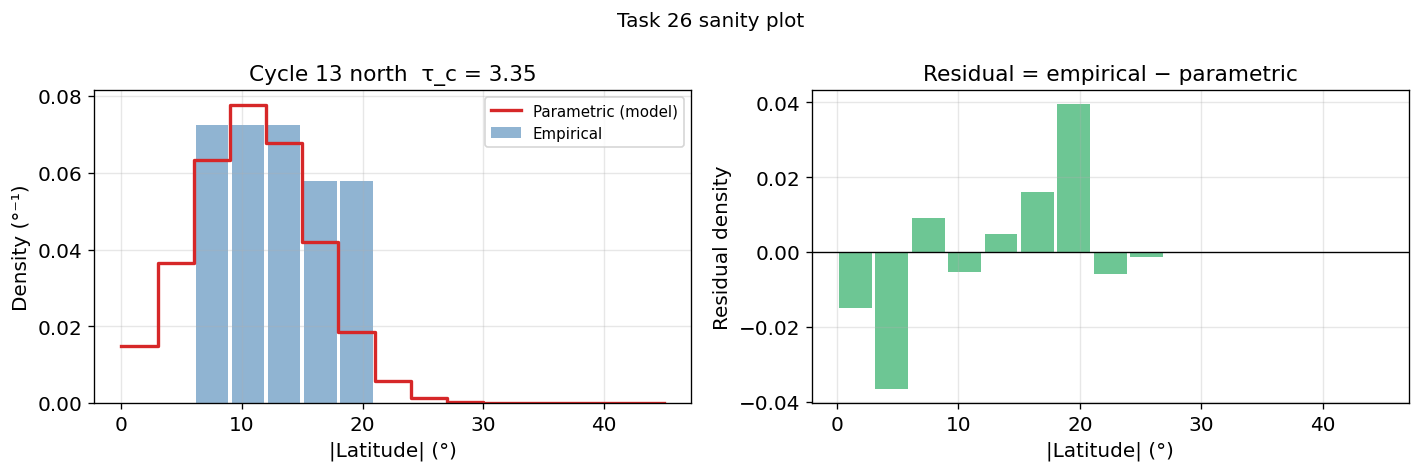

Residual integral ≈ 0.0162  (≈ 0 if both integrate to 1)


In [8]:

# Task 26 — Build the per-window dataset table

LAT_BINS    = np.linspace(0, 45, 16)          # 16 edges → 15 bins, 3° each
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

rows = []
for cyc, hemi in model.known_hemicycles():
    A = amp_lookup.get((int(cyc), hemi))
    if A is None:
        continue

    mask_hc = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi)
    df_hc   = df[mask_hc].copy()
    if len(df_hc) < 20:
        continue

    d_min = df_hc["date"].min()
    d_max = df_hc["date"].max()

    # Non-overlapping 6-month windows anchored on Jan 1 and Jul 1
    y_start    = d_min.year
    y_end      = d_max.year + 1
    boundaries = sorted({pd.Timestamp(y, m, 1)
                         for y in range(y_start, y_end + 1) for m in (1, 7)})

    smooth = smooth_north if hemi == "north" else smooth_south

    for i in range(len(boundaries) - 1):
        w_start, w_end = boundaries[i], boundaries[i + 1]

        if w_end <= d_min or w_start > d_max:
            continue

        mask_win = (df_hc["date"] >= w_start) & (df_hc["date"] < w_end)
        df_win   = df_hc[mask_win]
        if len(df_win) < 20:
            continue

        # Window centre → τ and universal mean latitude
        center_ts      = w_start + (w_end - w_start) / 2
        center_decimal = center_ts.year + center_ts.dayofyear / 365.25
        tau_center     = model.to_tau(cyc, hemi, center_decimal)
        mu_universal   = float(model.mu(tau_center))

        # 12-month-smoothed area at the window centre
        area_val      = smooth.asof(center_ts)
        area_smoothed = float(area_val) if pd.notna(area_val) else 0.0

        # Empirical density: histogram of |abs_latitude| on the bin grid
        hist_emp, _ = np.histogram(df_win["abs_latitude"].values,
                                   bins=LAT_BINS, density=True)

        # Parametric density: integrate the official-model Gaussian over each bin
        sigma_t = float(model.sigma(mu_universal, A))
        if sigma_t <= 0:
            continue
        hist_par = np.array([
            (sp_norm.cdf(LAT_BINS[j + 1], loc=mu_universal, scale=sigma_t) -
             sp_norm.cdf(LAT_BINS[j],     loc=mu_universal, scale=sigma_t)) / BIN_WIDTH
            for j in range(15)
        ])

        row = dict(cycle=int(cyc), hemisphere=hemi, amplitude=A,
                   tau_center=tau_center, mu_universal=mu_universal,
                   area_smoothed=area_smoothed)
        for j in range(15):
            row[f"hist_emp_{j:02d}"] = float(hist_emp[j])
            row[f"hist_par_{j:02d}"] = float(hist_par[j])
        rows.append(row)

windows_df = pd.DataFrame(rows).reset_index(drop=True)
n_hc       = windows_df.groupby(["cycle", "hemisphere"]).ngroups
print(f"Total windows: {len(windows_df)}  across {n_hc} hemicycles")

# ── Sanity plot: one random window ──────────────────────────────────────────
rng_26         = np.random.default_rng(42)
idx_demo_26    = int(rng_26.integers(0, len(windows_df)))
row_demo_26    = windows_df.iloc[idx_demo_26]
hist_emp_demo  = row_demo_26[hist_cols].values
hist_par_demo  = row_demo_26[par_cols].values
residual_demo  = hist_emp_demo - hist_par_demo

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(BIN_CENTERS, hist_emp_demo, width=BIN_WIDTH * 0.9, alpha=0.6,
       color="steelblue", label="Empirical")
ax.step(LAT_BINS, np.append(hist_par_demo, hist_par_demo[-1]),
        where="post", color="tab:red", linewidth=2, label="Parametric (model)")
ax.set_xlabel("|Latitude| (°)");  ax.set_ylabel("Density (°⁻¹)")
ax.set_title(f"Cycle {int(row_demo_26['cycle'])} {row_demo_26['hemisphere']}  "
             f"τ_c = {row_demo_26['tau_center']:.2f}")
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(BIN_CENTERS, residual_demo, width=BIN_WIDTH * 0.9,
       color="mediumseagreen", alpha=0.75)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel("|Latitude| (°)");  ax.set_ylabel("Residual density")
ax.set_title("Residual = empirical − parametric")

fig.suptitle("Task 26 sanity plot", fontsize=12)
plt.tight_layout();  plt.show()

print(f"Residual integral ≈ {residual_demo.sum() * BIN_WIDTH:.4f}  (≈ 0 if both integrate to 1)")


---
## Task 27 — Stratified train / validation / test split

Diffusion training, like supervised training, needs three disjoint splits.
The roles, however, are slightly different from what you may be used to:

- **Training set:** what the model sees during gradient updates.
- **Validation set:** used for **early stopping** (decide when to halt
  training) and for **schedule / hyperparameter selection** (compare
  candidate noise schedules, network widths, weighting schemes). Touched
  many times during model development, but never used in gradient updates.
- **Test set:** touched only when reporting the final model's performance.
  If you tune anything against the test set, your reported numbers are
  optimistic and will not reproduce.

The split is by **hemispheric cycle**, not by row. Two different windows
of the same hemispheric cycle are not independent observations: they share
the same amplitude, the same per-cycle shape parameters, and overlapping
physics. Splitting by row would leak information from train to validation
and inflate your scores.

We further want the split to be **stratified by cycle amplitude** so that
all three sets contain a representative mix of strong and weak cycles. A
random split could land all the weakest cycles in the test set and produce
a useless evaluation.

**Tasks:**
- Build a table with one row per hemispheric cycle, columns
  `(cycle, hemisphere, amplitude)`, where `amplitude` is the same Task 18
  peak amplitude used in Task 26.
- Sort the table by amplitude, **strongest first**.
- Walk down the sorted list and assign every fifth cycle (starting from
  index 0) to the **test set** — this is uniform sampling along the
  amplitude axis, which is what stratification means in this context.
- From the remaining cycles, walk down the sorted list and assign every
  fifth cycle (starting from index 0 of the remainder) to the
  **validation set**.
- Everything left is the **training set**.
- **Sanity plot:** plot a histogram (or empirical CDF) of cycle amplitudes
  for each of the three sets on the same axes. The three distributions
  should look similar — same range, same overall shape. If one set is
  systematically biased toward strong or weak cycles, the stratification
  has gone wrong.

**Ramification:** with ~46 hemispheric cycles total, a 60/20/20 split
yields roughly 28 training, 9 validation, 9 test cycles. This is decisively
small-data territory. Cross-validation across the train/validation
boundary would give more statistically robust hyperparameter choices, and
is a natural Week 09 extension once the basic pipeline works.


Train : 16 hemicycles  |  232 windows
Val   :  4 hemicycles  |   55 windows
Test  :  6 hemicycles  |   86 windows


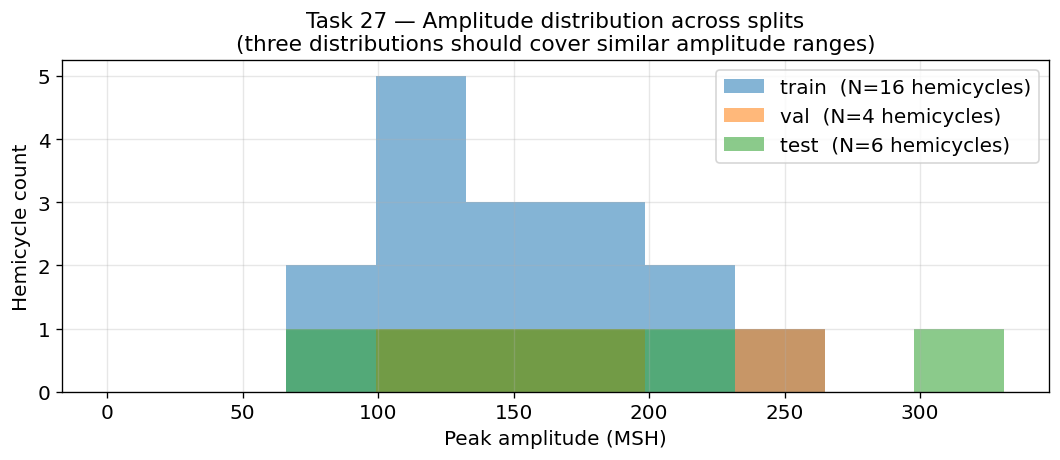

In [9]:

# Task 27 — Stratified train / validation / test split

# One row per hemicycle (using only hemicycles that have windows in windows_df)
hc_amp = (windows_df[["cycle", "hemisphere", "amplitude"]]
          .drop_duplicates()
          .sort_values("amplitude", ascending=False)   # strongest first
          .reset_index(drop=True))

# Every 5th row (0, 5, 10, …) → test set (uniform sampling along amplitude axis)
test_mask = np.zeros(len(hc_amp), dtype=bool)
test_mask[::5] = True

hc_test = hc_amp[test_mask].reset_index(drop=True)
hc_rest = hc_amp[~test_mask].reset_index(drop=True)

# From remaining, every 5th → validation set
val_mask = np.zeros(len(hc_rest), dtype=bool)
val_mask[::5] = True

hc_val   = hc_rest[val_mask].reset_index(drop=True)
hc_train = hc_rest[~val_mask].reset_index(drop=True)

# Tag every window row with its split label
test_keys = set(zip(hc_test["cycle"], hc_test["hemisphere"]))
val_keys  = set(zip(hc_val["cycle"],  hc_val["hemisphere"]))

def _split_label(row):
    key = (int(row["cycle"]), row["hemisphere"])
    if key in test_keys: return "test"
    if key in val_keys:  return "val"
    return "train"

windows_df["split"] = windows_df.apply(_split_label, axis=1)

print(f"Train : {len(hc_train):2d} hemicycles  |  {(windows_df['split']=='train').sum():3d} windows")
print(f"Val   : {len(hc_val):2d} hemicycles  |  {(windows_df['split']=='val').sum():3d} windows")
print(f"Test  : {len(hc_test):2d} hemicycles  |  {(windows_df['split']=='test').sum():3d} windows")

# ── Sanity plot: amplitude distributions should look similar across splits ────
fig, ax = plt.subplots(figsize=(9, 4))
amp_max  = hc_amp["amplitude"].max() * 1.05
amp_bins = np.linspace(0, amp_max, 11)
for label, color, hc in [("train", "tab:blue", hc_train),
                           ("val",   "tab:orange", hc_val),
                           ("test",  "tab:green",  hc_test)]:
    ax.hist(hc["amplitude"].values, bins=amp_bins, alpha=0.55, color=color,
            label=f"{label}  (N={len(hc)} hemicycles)")
ax.set_xlabel("Peak amplitude (MSH)")
ax.set_ylabel("Hemicycle count")
ax.set_title("Task 27 — Amplitude distribution across splits\n"
             "(three distributions should cover similar amplitude ranges)")
ax.legend()
plt.tight_layout();  plt.show()


In [10]:

# ── Save tables for use in downstream dataloaders ────────────────────────────
# Saved to the same directory as this notebook and official_model.npz.
_out_dir = Path(_week8_dir)

# 1. Full window table — parquet preserves float64 and is fast to reload.
#    Contains: metadata columns + 15 hist_emp_* + 15 hist_par_* + split label.
#    Residuals are computed on-the-fly by a DataLoader as hist_emp - hist_par.
_windows_path = _out_dir / "diffusion_windows.parquet"
windows_df.to_parquet(_windows_path, index=False)
print(f"Saved  {_windows_path.name}")
print(f"  shape : {windows_df.shape}")
print(f"  splits: {windows_df['split'].value_counts().sort_index().to_dict()}")

# 2. Hemicycle-level split index (light CSV for human inspection).
#    Lets downstream code re-apply the same train/val/test assignment without
#    recomputing the full window table.
hc_splits = (windows_df[["cycle", "hemisphere", "amplitude", "split"]]
             .drop_duplicates()
             .sort_values(["split", "cycle", "hemisphere"])
             .reset_index(drop=True))
_splits_path = _out_dir / "diffusion_cycle_splits.csv"
hc_splits.to_csv(_splits_path, index=False)
print(f"\nSaved  {_splits_path.name}")
print(hc_splits.to_string(index=False))

# ── Round-trip sanity check ───────────────────────────────────────────────────
_check = pd.read_parquet(_windows_path)
assert _check.shape == windows_df.shape
assert list(_check.columns) == list(windows_df.columns)
print(f"\nReload check passed — {len(_check)} rows × {len(_check.columns)} columns.")

# ── DataLoader usage hint ─────────────────────────────────────────────────────
print("""
To load in a downstream notebook or PyTorch DataLoader:

    import pandas as pd, numpy as np, torch
    from pathlib import Path

    _week8_dir = ...    # same path resolution as above
    windows    = pd.read_parquet(Path(_week8_dir) / "diffusion_windows.parquet")
    hist_cols  = [f"hist_emp_{j:02d}" for j in range(15)]
    par_cols   = [f"hist_par_{j:02d}" for j in range(15)]

    train = windows[windows["split"] == "train"]
    R     = torch.tensor(
                (train[hist_cols].values - train[par_cols].values),
                dtype=torch.float32)          # shape (N_train, 15)
    A     = torch.tensor(train["amplitude"].values,   dtype=torch.float32)
    tau   = torch.tensor(train["tau_center"].values,  dtype=torch.float32)
""")


Saved  diffusion_windows.parquet
  shape : (373, 37)
  splits: {'test': 86, 'train': 232, 'val': 55}

Saved  diffusion_cycle_splits.csv
 cycle hemisphere  amplitude split
    12      north  78.977266  test
    13      south 145.326301  test
    15      south 116.326014  test
    19      north 315.169904  test
    22      south 201.720781  test
    24      south 176.651173  test
    12      south 148.840101 train
    13      north  97.032734 train
    14      north 115.463211 train
    14      south  85.956981 train
    15      north 130.433748 train
    16      north 113.530553 train
    17      north 210.934282 train
    18      south 237.331422 train
    20      north 164.547860 train
    20      south 121.567348 train
    21      north 188.912463 train
    21      south 190.351575 train
    22      north 206.860307 train
    23      north 164.180940 train
    23      south 198.361699 train
    24      north 122.219016 train
    16      south 117.225545   val
    17      south 160.70

---
## Task 28 — Define the cosine noise schedule

The forward process corrupts a clean residual r into a noisy version r_t at
**timestep** t ∈ {0, 1, …, T} according to

$$r_t \;=\; \alpha_t \cdot r \;+\; \sigma_t \cdot \varepsilon, \qquad
\varepsilon \sim \mathcal{N}(0, I).$$

The pair (α_t, σ_t) is the **noise schedule**. It is fixed before training
begins, computed once, stored as two arrays of length T+1, and looked up by
index thereafter.

We use the **cosine schedule** of Nichol & Dhariwal (2021), which is
**variance-preserving**: α_t² + σ_t² = 1 at every t, so the total variance
of r_t stays bounded as t increases. This contrasts with the
**variance-exploding** family (used in some image-generation papers) where
σ_t grows without bound while α_t = 1 throughout. For low-dimensional data
like ours, variance-preserving is more stable and easier to train.

The cosine schedule defines a smooth function

$$\bar{\alpha}_t \;=\; \frac{\cos\!\big(\tfrac{\pi}{2} \cdot \tfrac{t/T + s}{1 + s}\big)^2}{\cos\!\big(\tfrac{\pi}{2} \cdot \tfrac{s}{1 + s}\big)^2}$$

with a small offset `s ≈ 0.008`, and then

$$\alpha_t = \sqrt{\bar{\alpha}_t}, \qquad \sigma_t = \sqrt{1 - \bar{\alpha}_t}.$$

The **signal-to-noise ratio** at timestep t is

$$\mathrm{SNR}(t) \;=\; \frac{\alpha_t^2}{\sigma_t^2} \;=\; \frac{\bar{\alpha}_t}{1 - \bar{\alpha}_t}.$$

It starts very large at t = 0 (almost pure signal), passes through 1 at the
schedule's halfway point, and falls toward 0 at t = T (almost pure noise).
The **shape of the SNR descent** is what the schedule actually controls;
α_t and σ_t are bookkeeping derived from it.

**Tasks:**
- Set `T = 200`. Implement the cosine schedule above with offset
  `s = 0.008`. Compute `alpha_bar` (length T+1), `alpha` (length T+1), and
  `sigma` (length T+1) as numpy arrays.
- For numerical stability, **clip** the per-step noise variance — define
  `beta_t = 1 - alpha_bar[t] / alpha_bar[t-1]` and clip `beta_t` to
  `[1e-8, 0.999]`. Recompute `alpha_bar` from the clipped `beta` if
  needed; this prevents pathological behaviour at the extreme timesteps.
- Plot α_t, σ_t, and SNR(t) on the same figure (use a log y-axis for SNR).
  Mark the timestep at which SNR(t) = 1 with a vertical line.
- **Reading the plot:** identify the timesteps where (i) the signal is
  almost untouched (high SNR), (ii) the signal is roughly half-corrupted
  (SNR ≈ 1), (iii) the signal is essentially gone (low SNR). These three
  regimes correspond to the three regimes the diffusion model has to
  handle next week.


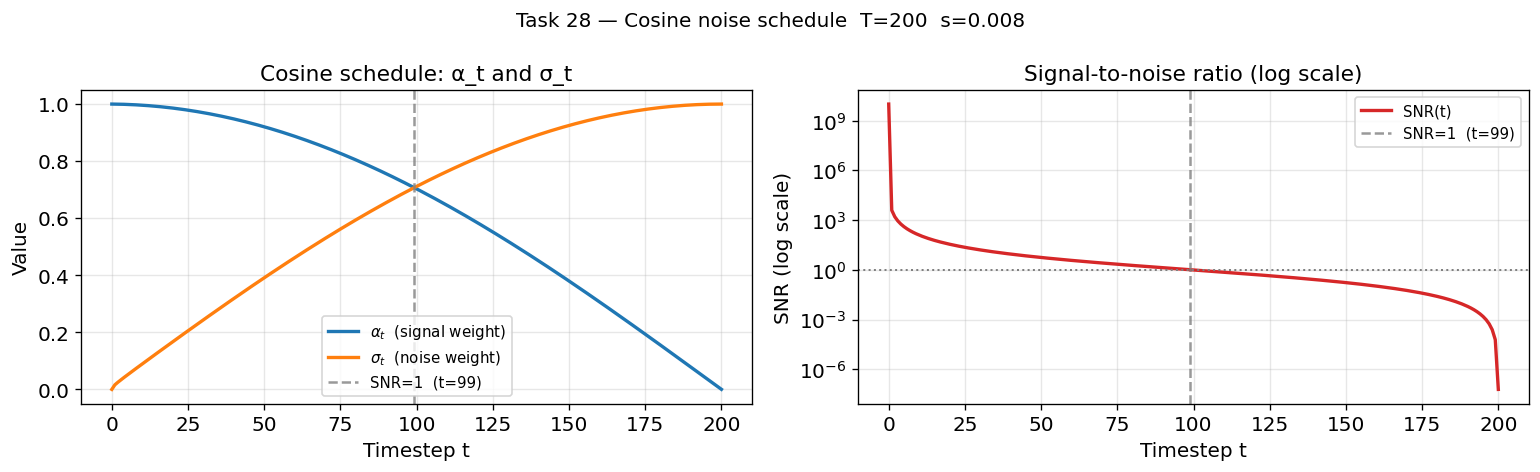

T=200, s=0.008
  α_0=1.000000   α_T=0.000246
  σ_0=0.000000   σ_T=1.000000
  SNR=1 at t=99

Three regimes:
  High SNR — signal nearly intact : t ≲ 33
  SNR ≈ 1  — roughly half-corrupted: t ≈ 99
  Low SNR  — essentially pure noise : t ≳ 198


In [11]:

# Task 28 — Cosine noise schedule

T = 200
s = 0.008

t_arr = np.arange(T + 1, dtype=float)

# Raw cosine schedule (Nichol & Dhariwal 2021)
f0            = np.cos(np.pi / 2 * s / (1 + s)) ** 2
alpha_bar_raw = np.cos(np.pi / 2 * (t_arr / T + s) / (1 + s)) ** 2 / f0
alpha_bar_raw = np.clip(alpha_bar_raw, 0.0, 1.0)

# Per-step noise beta_t clipped to [1e-8, 0.999] for numerical stability
beta    = np.zeros(T + 1)
beta[0] = 0.0
for t in range(1, T + 1):
    beta[t] = np.clip(1.0 - alpha_bar_raw[t] / alpha_bar_raw[t - 1], 1e-8, 0.999)

# Recompute alpha_bar from clipped betas so the two are consistent
alpha_bar    = np.ones(T + 1)
for t in range(1, T + 1):
    alpha_bar[t] = alpha_bar[t - 1] * (1.0 - beta[t])

alpha = np.sqrt(alpha_bar)
sigma = np.sqrt(np.clip(1.0 - alpha_bar, 0.0, 1.0))
SNR   = alpha_bar / np.maximum(1.0 - alpha_bar, 1e-10)

# Timestep where SNR = 1
t_snr1 = int(np.argmin(np.abs(SNR - 1.0)))

# ── Figure ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(t_arr, alpha, label=r"$\alpha_t$  (signal weight)", color="tab:blue",   linewidth=2)
ax1.plot(t_arr, sigma, label=r"$\sigma_t$  (noise weight)",  color="tab:orange", linewidth=2)
ax1.axvline(t_snr1, color="gray", linestyle="--", alpha=0.8, label=f"SNR=1  (t={t_snr1})")
ax1.set_xlabel("Timestep t");  ax1.set_ylabel("Value")
ax1.set_title("Cosine schedule: α_t and σ_t");  ax1.legend(fontsize=9)

ax2.semilogy(t_arr, SNR, color="tab:red", linewidth=2, label="SNR(t)")
ax2.axhline(1.0, color="gray", linestyle=":", linewidth=1.2)
ax2.axvline(t_snr1, color="gray", linestyle="--", alpha=0.8, label=f"SNR=1  (t={t_snr1})")
ax2.set_xlabel("Timestep t");  ax2.set_ylabel("SNR (log scale)")
ax2.set_title("Signal-to-noise ratio (log scale)");  ax2.legend(fontsize=9)

plt.suptitle(f"Task 28 — Cosine noise schedule  T={T}  s={s}", fontsize=12)
plt.tight_layout();  plt.show()

print(f"T={T}, s={s}")
print(f"  α_0={alpha[0]:.6f}   α_T={alpha[T]:.6f}")
print(f"  σ_0={sigma[0]:.6f}   σ_T={sigma[T]:.6f}")
print(f"  SNR=1 at t={t_snr1}")
print(f"\nThree regimes:")
print(f"  High SNR — signal nearly intact : t ≲ {t_snr1 // 3}")
print(f"  SNR ≈ 1  — roughly half-corrupted: t ≈ {t_snr1}")
print(f"  Low SNR  — essentially pure noise : t ≳ {min(T, t_snr1 * 2)}")


---
## Task 29 — Forward corruption: from clean residual to noise level t in one step

The forward process is mathematically a **Markov chain** of T small noising
steps from t to t+1, but the closed-form expression r_t = α_t·r + σ_t·ε
lets you jump from t = 0 to *any* t in a single call. This is what makes
training tractable: at each gradient step you sample a random t, corrupt
the clean residual to that t directly, and ask the network to undo it. You
never simulate the chain.

**Tasks:**
- Implement a function `forward_corrupt(r, t, alpha, sigma, rng=None)`
  that takes a clean residual `r` of shape `(15,)`, an integer timestep
  `t`, the schedule arrays from Task 28, and an optional `numpy.random.Generator`
  for reproducibility, and returns:
  - `r_t` — the noisy residual, shape `(15,)`.
  - `eps` — the noise sample that was added, shape `(15,)`.
  Returning both is important for next week: the training objective will
  ask the network to predict `eps` from `r_t`, so we need both during
  training data generation.
- Add a vectorised variant `forward_corrupt_batch(R, t_array, alpha, sigma, rng=None)`
  that takes `R` of shape `(N, 15)` and `t_array` of shape `(N,)` (a
  *different* timestep for each row) and returns `(R_t, EPS)` of the same
  shape. This is the version next week's training loop will call.
- **Sanity check:** apply `forward_corrupt(r, 0, ...)` to a real residual.
  The output `r_t` should equal `r` to floating-point precision and `eps`
  can be anything (it will be multiplied by σ_0 ≈ 0). Apply
  `forward_corrupt(r, T, ...)`: the output should be dominated by `eps`
  and bear no obvious resemblance to `r`.


In [12]:

# Task 29 — Forward corruption

def forward_corrupt(r, t, alpha, sigma, rng=None):
    """Corrupt clean residual r to noise level t in one step.

    r_t = alpha[t] * r + sigma[t] * eps,   eps ~ N(0, I)

    Parameters
    ----------
    r     : ndarray (15,) — clean residual
    t     : int           — diffusion timestep in [0, T]
    alpha : ndarray (T+1,)
    sigma : ndarray (T+1,)
    rng   : numpy.random.Generator, optional

    Returns
    -------
    r_t : ndarray (15,)
    eps : ndarray (15,)   — the noise sample (needed for training target)
    """
    if rng is None:
        rng = np.random.default_rng()
    eps = rng.standard_normal(r.shape).astype(r.dtype)
    r_t = alpha[t] * r + sigma[t] * eps
    return r_t, eps


def forward_corrupt_batch(R, t_array, alpha, sigma, rng=None):
    """Vectorised forward corruption — one different timestep per row.

    Parameters
    ----------
    R       : ndarray (N, 15) — clean residuals
    t_array : ndarray (N,) int — one timestep per row
    alpha, sigma : ndarray (T+1,)
    rng     : numpy.random.Generator, optional

    Returns
    -------
    R_t : ndarray (N, 15)
    EPS : ndarray (N, 15)
    """
    if rng is None:
        rng = np.random.default_rng()
    EPS = rng.standard_normal(R.shape).astype(R.dtype)
    a_t = alpha[t_array][:, None]   # (N, 1) for broadcasting
    s_t = sigma[t_array][:, None]
    R_t = a_t * R + s_t * EPS
    return R_t, EPS


# ── Sanity checks ────────────────────────────────────────────────────────────
train_df = windows_df[windows_df["split"] == "train"].reset_index(drop=True)
r_check  = (train_df.iloc[0][hist_cols].values
            - train_df.iloc[0][par_cols].values).astype(float)

r_t0, _ = forward_corrupt(r_check, 0, alpha, sigma, rng=np.random.default_rng(0))
r_tT, _ = forward_corrupt(r_check, T, alpha, sigma, rng=np.random.default_rng(1))

print("Sanity checks — forward_corrupt:")
print(f"  t=0 : max |r_t − r|   = {np.abs(r_t0 - r_check).max():.2e}  (should be ≈ 0)")
print(f"  t=T : corr(r_t, r)    = {np.corrcoef(r_tT, r_check)[0, 1]:.4f}  (should be ≈ 0)")
print(f"  t=T : std(r_t)        = {r_tT.std():.4f}  (expected σ_T = {sigma[T]:.4f})")

# Batch sanity
R_all    = (train_df[hist_cols].values - train_df[par_cols].values).astype(float)
t_random = np.random.default_rng(7).integers(0, T + 1, size=len(R_all))
R_t, EPS = forward_corrupt_batch(R_all, t_random, alpha, sigma, rng=np.random.default_rng(7))
print(f"\nBatch sanity: R_t shape = {R_t.shape}  EPS shape = {EPS.shape}  "
      f"(both should be {R_all.shape})")


Sanity checks — forward_corrupt:
  t=0 : max |r_t − r|   = 0.00e+00  (should be ≈ 0)
  t=T : corr(r_t, r)    = -0.1909  (should be ≈ 0)
  t=T : std(r_t)        = 0.6016  (expected σ_T = 1.0000)

Batch sanity: R_t shape = (232, 15)  EPS shape = (232, 15)  (both should be (232, 15))


---
## Task 30 — Visualize the forward trajectory

This is the headline visualization of the week. A picture of one residual
being progressively destroyed by the forward process is the conceptual
anchor for everything in Weeks 08 and 09. If a colleague who has never
seen diffusion asks you to explain what it is, this is the figure you
will show them.

**Tasks:**
- Pick one specific row from your training table that has a visually
  interesting residual — ideally one where the empirical histogram shows
  **bimodality** or asymmetric tails that the parametric Gaussian misses.
  Print its `(cycle, hemisphere, tau_center)` so the choice is reproducible.
- Apply `forward_corrupt` at six representative timesteps:
  `t ∈ {0, T/8, T/4, T/2, 3T/4, T}`. Use the *same* random seed for all
  six so the trajectory is deterministic and the comparison is fair —
  what changes between subplots is only the noise level, not the noise
  realization.
- Plot all six on a 2 × 3 grid of subplots. Each subplot shows:
  - the noisy residual r_t as a bar chart on the 15-bin latitude grid;
  - the SNR(t) value in the title.
  Use the same y-axis limits across all subplots so the eye can track the
  growing variance.
- Underneath, plot the **same six trajectories with a different random
  seed** and observe that at high SNR (low t) the trajectories agree
  closely, while at low SNR (high t) they diverge — different noise
  realizations produce visibly different r_t, even from the same r and t.
  This previews the intrinsic stochasticity of the forward process that
  Task 32 examines quantitatively.


Selected row:  cycle=14  hemisphere=south  τ_center=-1.463  amplitude=86 MSH


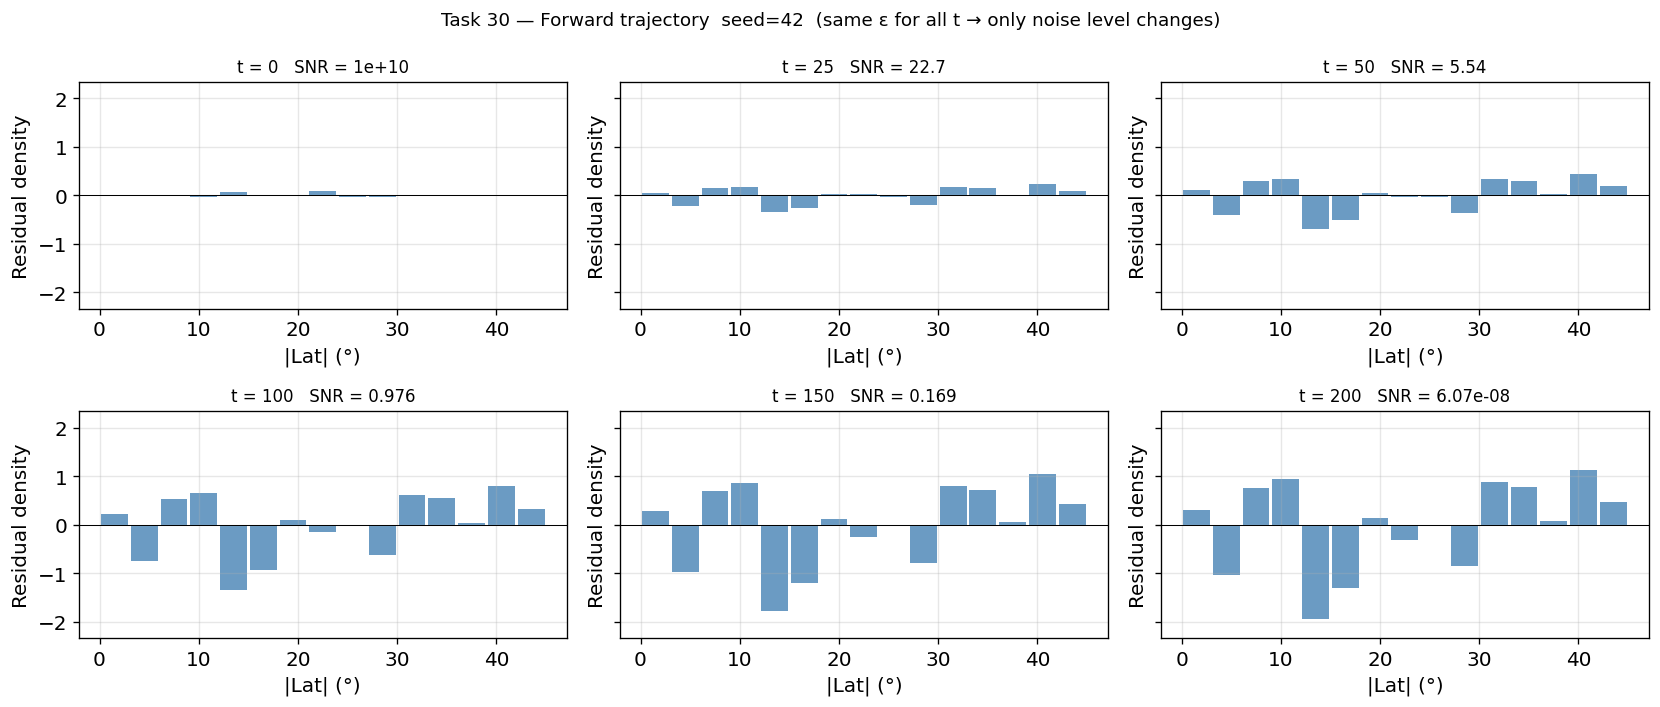

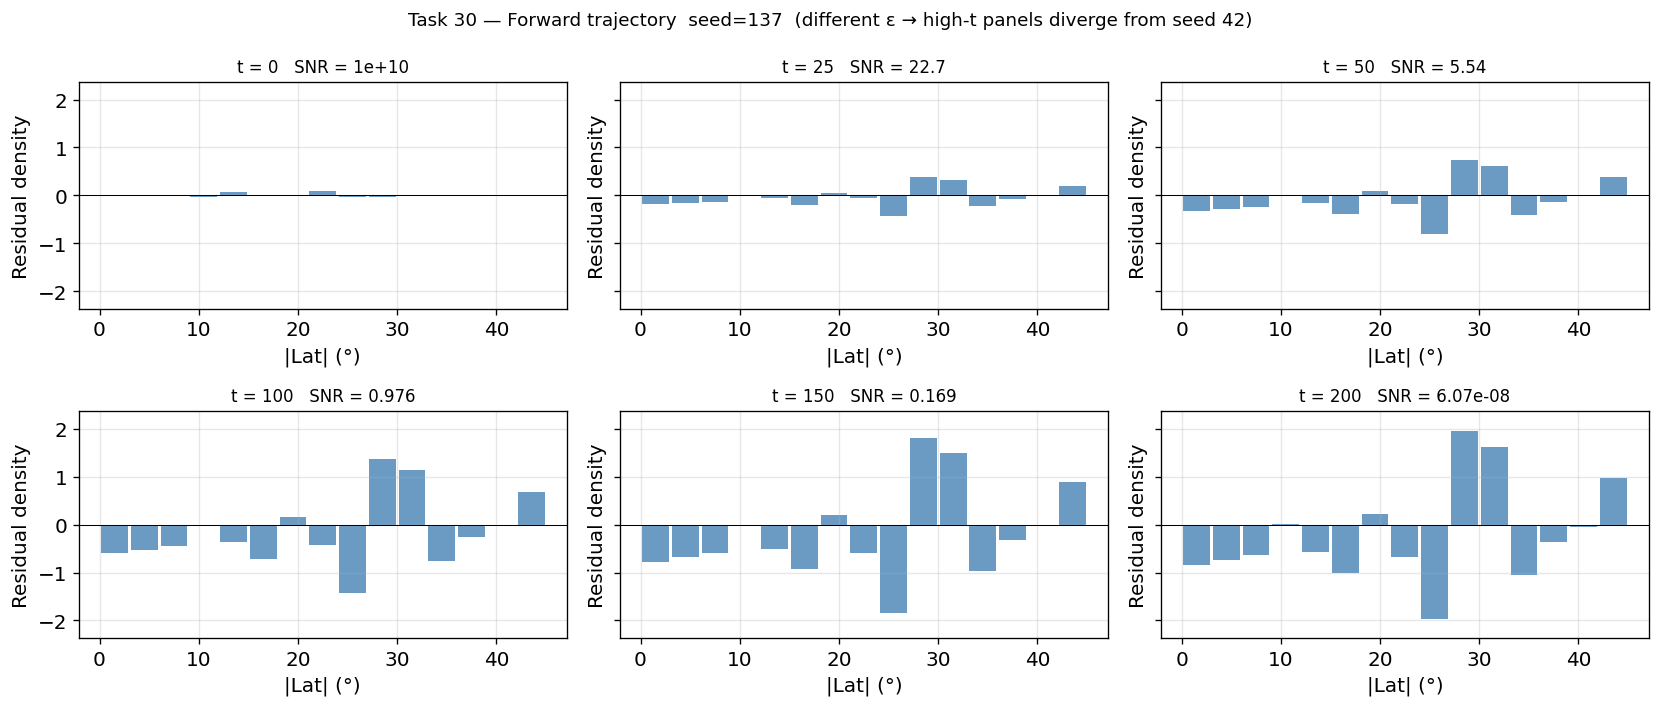

In [13]:

# Task 30 — Visualize the forward trajectory

train_df = windows_df[windows_df["split"] == "train"].reset_index(drop=True)
R_train  = (train_df[hist_cols].values - train_df[par_cols].values).astype(float)

# Pick the row with the highest residual variance — most likely bimodal / asymmetric
interesting_idx = int(np.argmax(np.var(R_train, axis=1)))
row_sel  = train_df.iloc[interesting_idx]
r_demo   = R_train[interesting_idx]

print(f"Selected row:  cycle={int(row_sel['cycle'])}  "
      f"hemisphere={row_sel['hemisphere']}  "
      f"τ_center={row_sel['tau_center']:.3f}  "
      f"amplitude={row_sel['amplitude']:.0f} MSH")

timesteps_30 = [0, T // 8, T // 4, T // 2, 3 * T // 4, T]


def _plot_trajectory(r, timesteps, alpha, sigma, SNR, rng_seed, suptitle=""):
    """Plot a 2×3 grid showing r_t at six noise levels from the same ε draw."""
    eps = np.random.default_rng(rng_seed).standard_normal(r.shape)

    corrupted = {t: alpha[t] * r + sigma[t] * eps for t in timesteps}
    all_vals  = np.concatenate(list(corrupted.values()))
    y_lim     = max(abs(all_vals.min()), abs(all_vals.max())) * 1.2

    fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
    for ax, t in zip(axes.flat, timesteps):
        ax.bar(BIN_CENTERS, corrupted[t], width=BIN_WIDTH * 0.9,
               color="steelblue", alpha=0.80)
        ax.axhline(0, color="k", linewidth=0.6)
        ax.set_xlabel("|Lat| (°)");  ax.set_ylabel("Residual density")
        ax.set_title(f"t = {t}   SNR = {SNR[t]:.3g}", fontsize=10)
        ax.set_ylim(-y_lim, y_lim)
    fig.suptitle(suptitle, fontsize=11)
    plt.tight_layout();  plt.show()


_plot_trajectory(r_demo, timesteps_30, alpha, sigma, SNR, rng_seed=42,
                 suptitle="Task 30 — Forward trajectory  seed=42  "
                           "(same ε for all t → only noise level changes)")

_plot_trajectory(r_demo, timesteps_30, alpha, sigma, SNR, rng_seed=137,
                 suptitle="Task 30 — Forward trajectory  seed=137  "
                           "(different ε → high-t panels diverge from seed 42)")


---
## Task 31 — Verify the limiting behaviour at t = T

A property of variance-preserving schedules is that as t → T, the
distribution of r_t converges to the standard Gaussian N(0, I) — and
crucially, this limit is **independent of the original data**. The
distribution at t = T does not "remember" what residuals you started from.
This is why next week's reverse process can begin from a fresh draw of
N(0, I) without any learning at the first step: at t = T, *all* clean
residuals corrupt to the same distribution, so we can sample that
distribution analytically rather than learning it.

This task asks you to verify the limiting behaviour empirically.

**Tasks:**
- Take the full **training set** of clean residuals (one residual per
  6-month window in the training cycles). Apply `forward_corrupt_batch`
  with `t_array = T` for every row — i.e., corrupt every training
  residual all the way to t = T, each with an independent fresh ε draw.
- For the resulting set of noised residuals at t = T:
  - Compute the **bin-wise mean** across all rows (a vector of length 15).
    Plot it as a bar chart. It should be statistically indistinguishable
    from zero, with bin-wise standard error roughly 1/√N where N is the
    number of training rows.
  - Compute the **bin-wise standard deviation** across all rows. Plot it
    as a bar chart. It should be statistically indistinguishable from 1,
    in every bin.
  - Compute the **bin-bin covariance matrix** (shape 15 × 15) and display
    it as a heatmap. It should look like the identity matrix to plotting
    precision: ~1 on the diagonal, ~0 off-diagonal.
- **Counter-test:** repeat the same three diagnostics on the *clean*
  training residuals (i.e., t = 0). The mean is non-zero in some bins,
  the standard deviation is bin-dependent, and the covariance matrix has
  off-diagonal structure. The contrast between the t = 0 and t = T
  diagnostics is exactly the structure the diffusion model has to learn
  to generate, run in reverse.


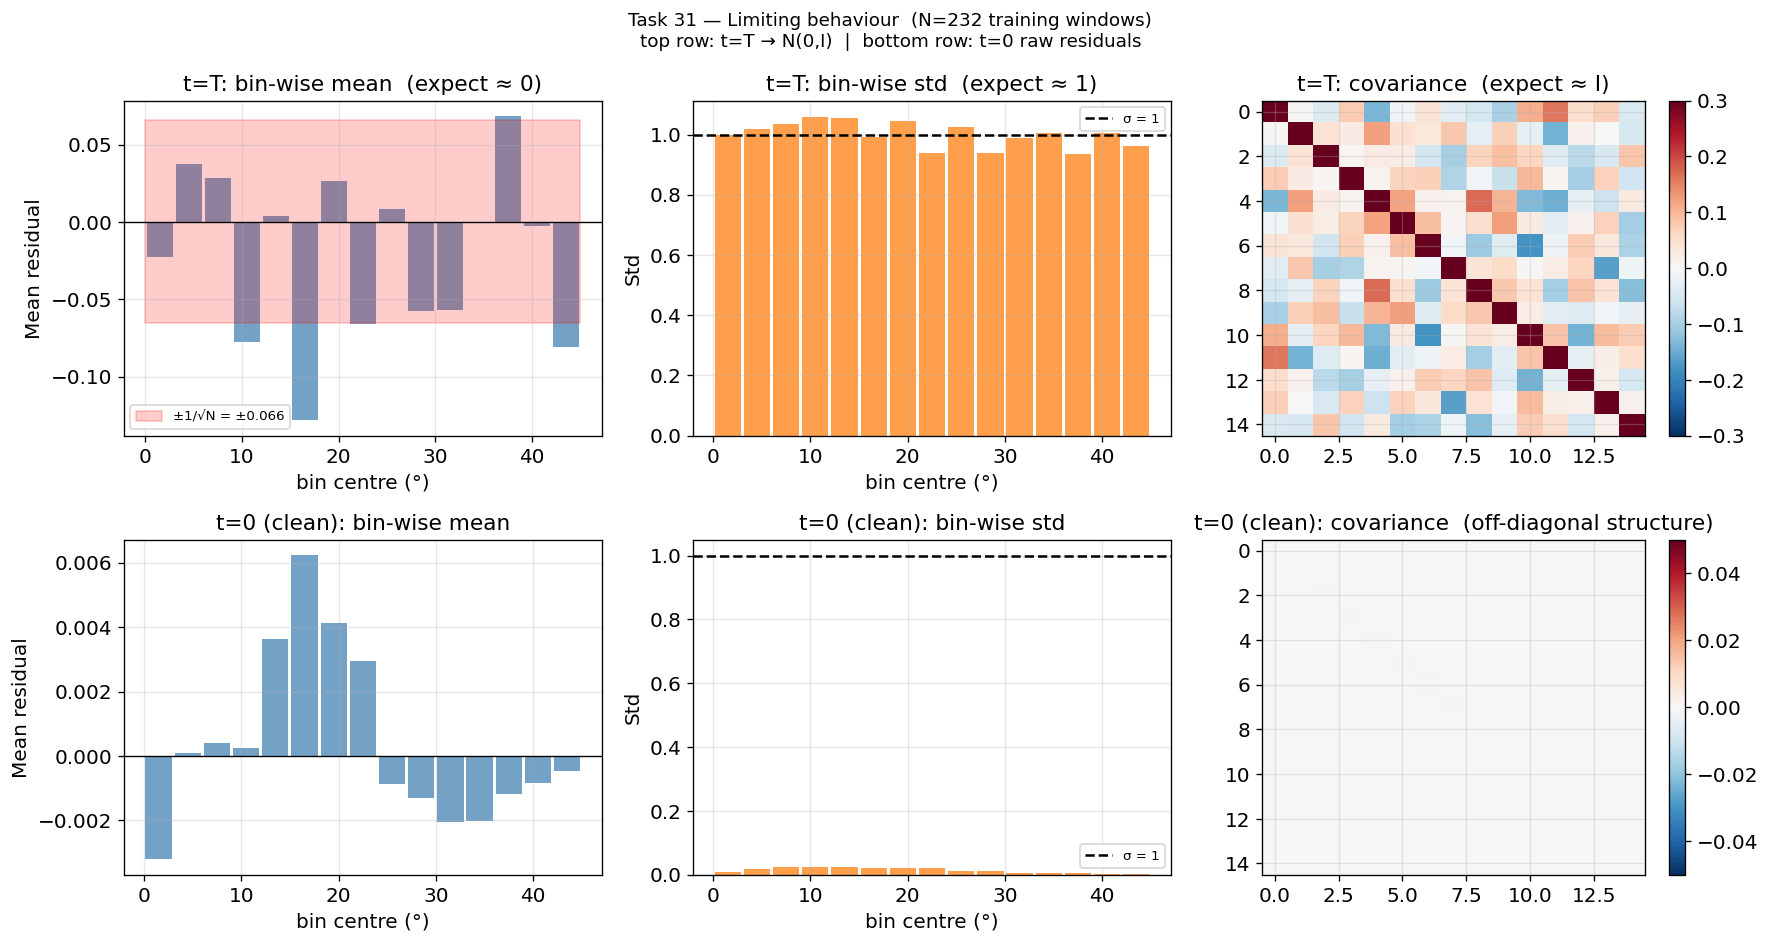

N = 232 training windows

  t=T  mean  [-0.1284, 0.0686]  (expect 0 ± 0.0657)
  t=T  std   [0.9370, 1.0598]   (expect 1.0000)
  t=T  off-diag |Σ-I| max = 0.1804  (expect ≈ 0)

  t=0  mean  [-0.0032, 0.0062]
  t=0  std   [0.0015, 0.0233]


In [14]:

# Task 31 — Verify the limiting behaviour at t = T

train_df = windows_df[windows_df["split"] == "train"].reset_index(drop=True)
R_clean  = (train_df[hist_cols].values - train_df[par_cols].values).astype(float)
N        = len(R_clean)

# Corrupt every training residual all the way to t = T with independent ε draws
t_all_T      = np.full(N, T, dtype=int)
R_noisy_T, _ = forward_corrupt_batch(R_clean, t_all_T, alpha, sigma,
                                     rng=np.random.default_rng(42))

# Compute diagnostics for t=T and t=0
mean_T  = R_noisy_T.mean(axis=0);  std_T = R_noisy_T.std(axis=0)
cov_T   = np.cov(R_noisy_T.T)
mean_0  = R_clean.mean(axis=0);    std_0 = R_clean.std(axis=0)
cov_0   = np.cov(R_clean.T)

se = 1.0 / np.sqrt(N)   # expected std-error of the mean under N(0,I)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ── row 0: t = T (should look like N(0, I)) ──────────────────────────────────
ax = axes[0, 0]
ax.bar(BIN_CENTERS, mean_T, width=BIN_WIDTH * 0.9, color="steelblue", alpha=0.75)
ax.axhline(0, color="k", linewidth=0.8)
ax.fill_between([0, 45], [-se, -se], [se, se], color="red", alpha=0.20,
                label=f"±1/√N = ±{se:.3f}")
ax.set_title("t=T: bin-wise mean  (expect ≈ 0)");  ax.legend(fontsize=8)
ax.set_xlabel("bin centre (°)");  ax.set_ylabel("Mean residual")

ax = axes[0, 1]
ax.bar(BIN_CENTERS, std_T, width=BIN_WIDTH * 0.9, color="tab:orange", alpha=0.75)
ax.axhline(1.0, color="k", linewidth=1.5, linestyle="--", label="σ = 1")
ax.set_title("t=T: bin-wise std  (expect ≈ 1)");  ax.legend(fontsize=8)
ax.set_xlabel("bin centre (°)");  ax.set_ylabel("Std")

ax = axes[0, 2]
im = ax.imshow(cov_T, aspect="auto", cmap="RdBu_r", vmin=-0.3, vmax=0.3)
ax.set_title("t=T: covariance  (expect ≈ I)")
plt.colorbar(im, ax=ax)

# ── row 1: t = 0 (clean residuals — structural non-Gaussianity) ──────────────
ax = axes[1, 0]
ax.bar(BIN_CENTERS, mean_0, width=BIN_WIDTH * 0.9, color="steelblue", alpha=0.75)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("t=0 (clean): bin-wise mean")
ax.set_xlabel("bin centre (°)");  ax.set_ylabel("Mean residual")

ax = axes[1, 1]
ax.bar(BIN_CENTERS, std_0, width=BIN_WIDTH * 0.9, color="tab:orange", alpha=0.75)
ax.axhline(1.0, color="k", linewidth=1.5, linestyle="--", label="σ = 1")
ax.set_title("t=0 (clean): bin-wise std");  ax.legend(fontsize=8)
ax.set_xlabel("bin centre (°)");  ax.set_ylabel("Std")

ax = axes[1, 2]
vmax0 = max(float(np.abs(cov_0).max()), 0.05)
im2   = ax.imshow(cov_0, aspect="auto", cmap="RdBu_r", vmin=-vmax0, vmax=vmax0)
ax.set_title("t=0 (clean): covariance  (off-diagonal structure)")
plt.colorbar(im2, ax=ax)

fig.suptitle(f"Task 31 — Limiting behaviour  (N={N} training windows)\n"
             "top row: t=T → N(0,I)  |  bottom row: t=0 raw residuals", fontsize=11)
plt.tight_layout();  plt.show()

print(f"N = {N} training windows")
print(f"\n  t=T  mean  [{mean_T.min():.4f}, {mean_T.max():.4f}]  (expect 0 ± {se:.4f})")
print(f"  t=T  std   [{std_T.min():.4f}, {std_T.max():.4f}]   (expect 1.0000)")
off_diag = np.abs(cov_T - np.eye(15)); np.fill_diagonal(off_diag, 0)
print(f"  t=T  off-diag |Σ-I| max = {off_diag.max():.4f}  (expect ≈ 0)")
print(f"\n  t=0  mean  [{mean_0.min():.4f}, {mean_0.max():.4f}]")
print(f"  t=0  std   [{std_0.min():.4f}, {std_0.max():.4f}]")


---
## Task 32 — The forward process is stochastic: many r_t's per (r, t)

A subtle point that often confuses students on first contact with
diffusion: the forward process is *not* a deterministic function of (r, t).
The same clean residual r corrupted at the same noise level t can produce
many different noisy residuals r_t — one per draw of ε. The forward
process maps each (r, t) to a **distribution** over r_t, not a single r_t.

This is why the reverse process must be a *learned* model rather than
a closed-form inverse: there is no inverse function, because the forward
process is many-to-one (in fact, many-to-many). The reverse model has to
estimate, for each noisy r_t, the most likely direction back toward the
clean data manifold — and "most likely" is a statement about a
distribution, which is what a neural network is good at approximating.

**Tasks:**
- Pick the same row you used in Task 30. Pick one intermediate timestep,
  say `t = T // 4`. Call `forward_corrupt(r, t, ...)` **100 times**, each
  with a different random seed. Collect the 100 noisy residuals into an
  array of shape `(100, 15)`.
- Plot all 100 noisy residuals on the same axes as faint lines, with the
  *clean* residual r overlaid as a thick black line. The cloud of faint
  lines should cluster around r with bin-wise spread proportional to σ_t.
- Compute the empirical mean and standard deviation across the 100
  samples in each bin, and overlay them as error bars on the clean
  residual. Verify that:
  - the empirical bin-wise mean ≈ α_t · r (the deterministic part of the
    corruption);
  - the empirical bin-wise standard deviation ≈ σ_t (the stochastic part).
- Repeat for t = T // 2 and t = 3T // 4. Watch the cloud spread out as
  σ_t grows and the deterministic centerline α_t·r shrinks toward zero.

This is the cleanest illustration of the forward process's structure
α_t (deterministic) + σ_t (stochastic) that you will see all week.


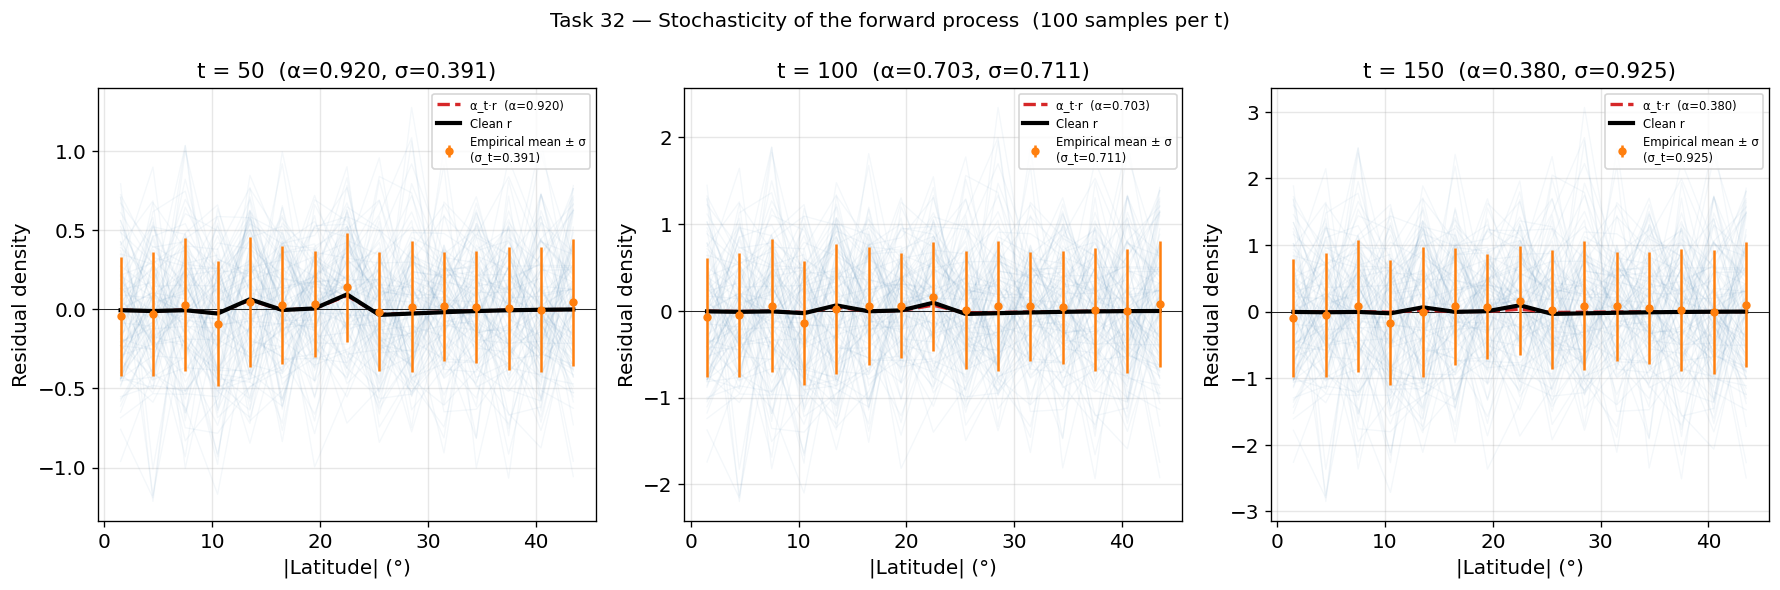

Row: cycle=14, hemisphere=south, τ_center=-1.463

   t      α_t      σ_t    |mean − α·r|   |std − σ_t|
───────────────────────────────────────────────────────
  50   0.9203   0.3911         0.03110       0.02186
 100   0.7027   0.7114         0.05657       0.03976
 150   0.3798   0.9251         0.07356       0.05170

Expected mean error ≈ σ_t / √100 ≈ σ_t / 10
Both columns should be small relative to σ_t — the law of large numbers in action.


In [15]:

# Task 32 — The forward process is stochastic: many r_t's per (r, t)
# Requires r_demo and row_sel from Task 30.

N_SAMPLES    = 100
timesteps_32 = [T // 4, T // 2, 3 * T // 4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, t in zip(axes, timesteps_32):
    # Draw N_SAMPLES independent noisy versions at this t
    samples = np.array([
        forward_corrupt(r_demo, t, alpha, sigma,
                        rng=np.random.default_rng(seed))[0]
        for seed in range(N_SAMPLES)
    ])
    emp_mean = samples.mean(axis=0)
    emp_std  = samples.std(axis=0)

    # Faint cloud of all samples
    for j in range(N_SAMPLES):
        ax.plot(BIN_CENTERS, samples[j], color="steelblue", alpha=0.06, linewidth=0.8)

    # Deterministic centre-line: alpha[t] * r
    ax.plot(BIN_CENTERS, alpha[t] * r_demo, color="tab:red", linewidth=2,
            linestyle="--", label=f"α_t·r  (α={alpha[t]:.3f})", zorder=4)

    # Clean residual
    ax.plot(BIN_CENTERS, r_demo, color="black", linewidth=2.5,
            label="Clean r", zorder=5)

    # Empirical mean ± empirical std as error bars
    ax.errorbar(BIN_CENTERS, emp_mean, yerr=emp_std, fmt="o",
                color="tab:orange", markersize=4, linewidth=1.5, zorder=6,
                label=f"Empirical mean ± σ\n(σ_t={sigma[t]:.3f})")

    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_xlabel("|Latitude| (°)");  ax.set_ylabel("Residual density")
    ax.set_title(f"t = {t}  (α={alpha[t]:.3f}, σ={sigma[t]:.3f})")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(f"Task 32 — Stochasticity of the forward process  "
             f"({N_SAMPLES} samples per t)", fontsize=12)
plt.tight_layout();  plt.show()

# ── Numerical verification ───────────────────────────────────────────────────
print(f"Row: cycle={int(row_sel['cycle'])}, hemisphere={row_sel['hemisphere']}, "
      f"τ_center={row_sel['tau_center']:.3f}\n")
print(f"{'t':>4}  {'α_t':>7}  {'σ_t':>7}  {'|mean − α·r|':>14}  {'|std − σ_t|':>12}")
print("─" * 55)
for t in timesteps_32:
    samp     = np.array([
        forward_corrupt(r_demo, t, alpha, sigma, rng=np.random.default_rng(s))[0]
        for s in range(N_SAMPLES)
    ])
    mean_err = np.abs(samp.mean(axis=0) - alpha[t] * r_demo).mean()
    std_err  = np.abs(samp.std(axis=0)  - sigma[t]).mean()
    print(f"{t:4d}  {alpha[t]:7.4f}  {sigma[t]:7.4f}  {mean_err:14.5f}  {std_err:12.5f}")

print(f"\nExpected mean error ≈ σ_t / √{N_SAMPLES} ≈ σ_t / {N_SAMPLES**0.5:.0f}")
print("Both columns should be small relative to σ_t — the law of large numbers in action.")


---
## Where Week 07 leaves us, and what Week 08 will need

By the end of Task 32 you have built every piece of diffusion-specific
machinery the model needs, in pure numpy:

- A **dataset** of residuals indexed by hemispheric cycle and 6-month
  window (Task 26).
- A **stratified train/val/test split** by cycle amplitude that respects
  the cycle-as-unit structure of the data (Task 27).
- A **cosine noise schedule** with all the bookkeeping (α, σ, SNR)
  needed by both training and sampling (Task 28).
- A **forward corruption function** that maps (r, t) → r_t in one step,
  vectorised over batches (Task 29).
- **Three independent verifications** that the forward process behaves
  the way the mathematics says it should (Tasks 30–32).

What you have **not** built is anything with learnable parameters. There
is no neural network in this notebook; there is no PyTorch in this
notebook; there is no training loop in this notebook. That is by design.
The forward process is where all the diffusion-specific math lives, and
you have implemented it transparently and verified it works.

Next week we will build the **reverse process**: a small denoising MLP,
trained in PyTorch + Lightning, whose job is to estimate ε from r_t. The
forward apparatus you built this week will be reused unchanged — it
generates the (r_t, t, ε) training triples the network learns from.
Nothing about Task 28's schedule, Task 29's forward function, or
Task 27's splits will change in Week 08. We are simply adding the
*learned* half of the model on top of the *numerical* half you have just
built.
